In [8]:
import numpy as np
import matplotlib.pyplot as plt
!pip install control
import control as ctrl

plt.rcParams.update({
    "font.size": 14})

# -----------------------------
# Propietats del sistema
# -----------------------------
# Motor
n_max = 3600    # rpm, velocitat maxima
Mm_n  = 3.53    # Nm, parell motor nominal
Mm_max= 12.2    # Nm, parell motor maxim
J_m   = 260e-6  # kg·m2, inercia del motor
b_m   = 1e-3    # Nms/rad, constant motor

# Cargol
pas = 10e-3     # m, pas cargol
D   = 23.2e-3   # m, diàmetre cargol
L   = 940e-3    # m, longitud
rho = 7.85e3    # kg/m3, densitat acer

# Acoblament
J_a = 30e-6     # kg/m2, inercia de l'acoblament
k_a = 120e-3   # Nm/rad, rigidesa angular acoblament

# Massa
m_carro = 1.35  # kg, massa del carro
M = 0           # kg, massa addicional

n_gdl = 2

In [9]:
# -----------------------------
# Propietats cargol
# -----------------------------
v_cargol = np.pi * D**2 / 4 * L
m_cargol = v_cargol * rho
J_cargol = 0.5 * m_cargol * (D/2)**2
i_n = pas / (2*np.pi)

In [10]:
# -----------------------------
# Matrius M,C,K
# -----------------------------
J11 = J_m + J_a/2
J22 = (J_a/2 + J_cargol)/i_n**2 + m_carro + M

C11 = b_m

K11 = k_a
K12 = -k_a/i_n
K22 = k_a/i_n**2

M_ = np.array([[J11, 0],
               [0,   J22]])

C_ = np.array([[C11, 0],
               [0,   0]])

K_ = np.array([[K11, K12],
               [K12, K22]])

# -----------------------------
# Espai d'estat
# -----------------------------
Z = np.zeros((n_gdl, n_gdl))
I = np.eye(n_gdl)

A = np.block([
    [Z, I],
    [-np.linalg.inv(M_) @ K_, -np.linalg.inv(M_) @ C_]])

B = np.vstack((np.zeros((n_gdl, n_gdl)), np.linalg.inv(M_)))
C = np.hstack((np.zeros((n_gdl, n_gdl)), I))
D = np.zeros((n_gdl, n_gdl))

model = ctrl.ss(A, B, C, D)

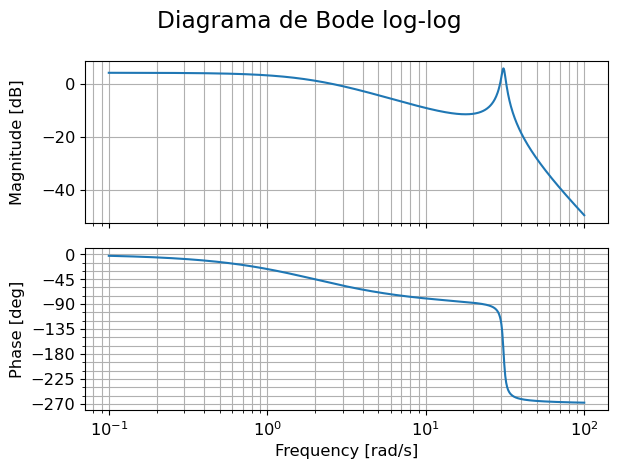

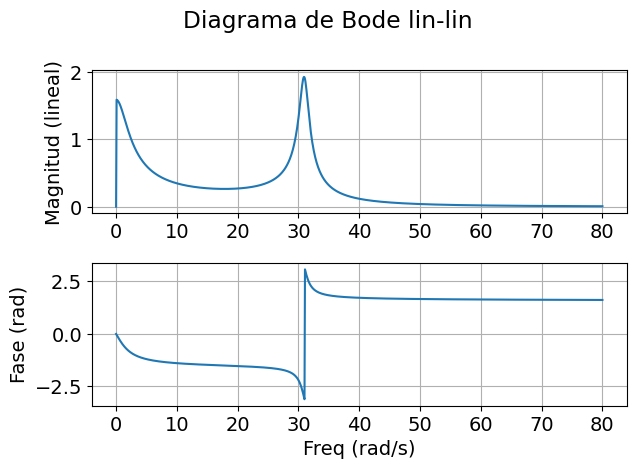

In [11]:
# -----------------------------
# BODE (equivalent a model(1,n_gdl))
# -----------------------------
# MATLAB: model(1,n_gdl) → sortida 1, entrada 2
sys_12 = model[0, 1]

# BODE log - log
# -----------------------------
plt.figure()
ctrl.bode(sys_12, dB=True)
plt.suptitle("Diagrama de Bode log-log")

# BODE lineal - linesl
# -----------------------------
omega = np.linspace(0, 80, 1000)
resp = ctrl.frequency_response(sys_12, omega)

plt.figure()

plt.subplot(2,1,1)
plt.plot(omega, resp.magnitude)
plt.ylabel("Magnitud (lineal)")
plt.grid()

plt.subplot(2,1,2)
plt.plot(omega, resp.phase)
plt.ylabel("Fase (rad)")
plt.xlabel("Freq (rad/s)")
plt.grid()

plt.suptitle("Diagrama de Bode lin-lin")
plt.tight_layout()
plt.show()

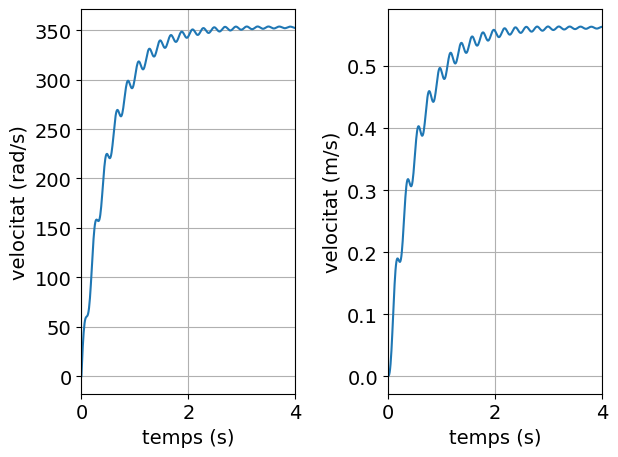

In [12]:
# -----------------------------
# Resposta escaló
# -----------------------------
M0 = Mm_n / 10

plt.figure()

plt.subplot(1,2,1)
t, y = ctrl.step_response(M0 * model[0,0])
plt.plot(t, y)
plt.grid()
plt.xlabel("temps (s)")
plt.ylabel("velocitat (rad/s)")
plt.xlim(0,4)

plt.subplot(1,2,2)
t, y = ctrl.step_response(M0 * model[0,1])
plt.plot(t, y)
plt.grid()
plt.xlabel("temps (s)")
plt.ylabel("velocitat (m/s)")
plt.xlim(0,4)

plt.tight_layout()
plt.show()

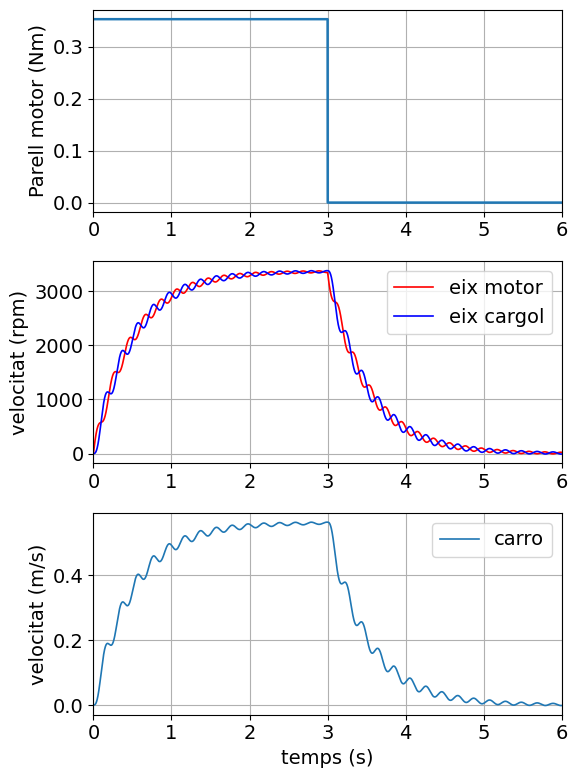

In [13]:
# -----------------------------
# Resposta temporal (lsim)
# -----------------------------
t_final = 6
t = np.linspace(0, t_final, 20000)

u = np.zeros((2, len(t)))
u[0, t <= 3] = M0   # Moment motor, actua només fins 3 segons

t, y = ctrl.forced_response(model, T=t, U=u)

plt.figure(figsize=(6,8))

plt.subplot(3,1,1)
plt.plot(t, u[0,:], linewidth=1.8)
plt.ylabel("Parell motor (Nm)")
plt.grid()
plt.xlim(0,6)

plt.subplot(3,1,2)
plt.plot(t, y[0,:]*30/np.pi, '-r', linewidth=1.2)
plt.plot(t, y[1,:]*30/np.pi/i_n, '-b', linewidth=1.2)
plt.legend(['eix motor','eix cargol'])
plt.ylabel("velocitat (rpm)")
plt.grid()
plt.xlim(0,6)

plt.subplot(3,1,3)
plt.plot(t, y[1,:], linewidth=1.2)
plt.legend(['carro'])
plt.xlabel("temps (s)")
plt.ylabel("velocitat (m/s)")
plt.grid()
plt.xlim(0,6)

plt.tight_layout()
plt.show()